In [18]:
import os, random, math
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import time
from torch.optim import Adam
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import numpy as np
from PIL import Image
import torchvision.transforms.functional as TF
import torch.fft
import matplotlib.pyplot as plt


In [19]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
project_path = "/content/drive/MyDrive/Colab Notebooks/Image-Restauration"

os.chdir(project_path)

print("Répertoire actuel :", os.getcwd())
print("Contenu du dossier :", os.listdir())

Répertoire actuel : /content/drive/MyDrive/Colab Notebooks/Image-Restauration
Contenu du dossier : ['IRCNN_v2', '.gitignore', '.DS_Store', 'README.md', 'inpaint_ircnn_drunet_shepard.py', '.git', '.venv', 'kernels', 'BSDS300']


In [ ]:
IMG_EXT = (".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff")

class FixedSigmaPatchDataset(Dataset):
    def __init__(self, clean_dir: str, patch: int = 35, sigma: float = 25.0):
        self.paths = [
            os.path.join(clean_dir, f) for f in os.listdir(clean_dir)
            if f.lower().endswith(IMG_EXT)
        ]
        if not self.paths:
            raise ValueError(f"No images found in {clean_dir}")
        self.patch = patch
        self.sigma = sigma

    def __len__(self):
        return 1000000

    def _random_crop(self, img: Image.Image) -> Image.Image:
        w, h = img.size
        if w < self.patch or h < self.patch:
            img = img.resize((max(w, self.patch), max(h, self.patch)), Image.BICUBIC)
            w, h = img.size
        x0 = random.randint(0, w - self.patch)
        y0 = random.randint(0, h - self.patch)
        return img.crop((x0, y0, x0 + self.patch, y0 + self.patch))

    def _augment(self, img: Image.Image) -> Image.Image:
        if random.random() < 0.5:
            img = TF.hflip(img)
        if random.random() < 0.5:
            img = TF.vflip(img)
        k = random.randint(0, 3)
        if k > 0:
            img = img.rotate(90 * k)
        return img

    def __getitem__(self, idx):
        path = random.choice(self.paths)
        img = Image.open(path).convert("RGB")
        img = self._random_crop(img)
        img = self._augment(img)

        clean = TF.to_tensor(img)

        noise = torch.randn_like(clean) * (self.sigma / 255.0)
        noisy = clean + noise

        return noisy, clean


class IRCNNFixed(nn.Module):
    """
    Input:  (B,3,H,W) = noisy RGB
    Output: (B,3,H,W) clean
    Residual learning: predict noise implicitly then subtract
    """
    def __init__(self, in_channels=3, n_filters=64):
        super(IRCNNFixed, self).__init__()
        dilations = [1, 2, 3, 4, 3, 2, 1]
        self.layers = nn.ModuleList()

        for i, d in enumerate(dilations):
            if i==0:
                self.layers.append(nn.Conv2d(in_channels, n_filters, 3, padding=d, dilation=d, bias=True))
                self.layers.append(nn.ReLU(inplace=True))
            elif i < 6:
                self.layers.append(nn.Conv2d(n_filters, n_filters, 3, padding=d, dilation=d, bias=False))
                self.layers.append(nn.BatchNorm2d(n_filters))
                self.layers.append(nn.ReLU(inplace=True))
            else:
                self.layers.append(nn.Conv2d(n_filters, in_channels, 3, padding=d, dilation=d, bias=True))


    def forward(self, x):
        noise_pred = x
        for layer in self.layers:
            noise_pred = layer(noise_pred)
        return noise_pred

    def denoise(self, x):
      return x - self.forward(x)


In [ ]:
def train_all_experts(
    clean_dir=r"./BSDS300/images/train",
    base_out_dir=r"./IRCNN_v2/weights_ircnn_experts_colab",
    patch=35,
    sigmas=[2*i for i in range(1,26)],
    batch_size=8,
    steps_per_epoch=500,
    max_epochs=5,
    lr0=1e-3,
    tolerance=0.015,
    log_every=50
):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = IRCNNFixed().to(device)
    loss_fn = nn.MSELoss()
    scaler = GradScaler(enabled=(device == "cuda"))

    for sigma in sigmas:

        out_dir = os.path.join(base_out_dir, f"sigma_{sigma}")
        os.makedirs(out_dir, exist_ok=True)

        ds = FixedSigmaPatchDataset(clean_dir, patch=patch, sigma=float(sigma))
        dl = DataLoader(
            ds, batch_size=batch_size, shuffle=True,
            num_workers=0, pin_memory=(device == "cuda"), drop_last=True
        )

        opt = Adam(model.parameters(), lr=lr0)
        best = float("inf")
        stagnant = 0
        using_lr1 = False
        previous_loss = float('inf')

        for epoch in range(1, max_epochs + 1):
            model.train()
            running = 0.0
            start_t = time.time()

            pbar = tqdm(total=steps_per_epoch, desc=f"Sigma {sigma} - Ep {epoch}/{max_epochs}", leave=True)
            for step, (noisy, clean) in enumerate(dl):
                if step >= steps_per_epoch:
                    break

                noisy = noisy.to(device, non_blocking=True)
                clean = clean.to(device, non_blocking=True)

                target_noise = noisy - clean

                with autocast(enabled=(device == "cuda")):
                    pred_noise = model.forward(noisy)
                    loss = loss_fn(pred_noise, target_noise)

                opt.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(opt)
                scaler.update()

                running += loss.item()

                if (step + 1) % log_every == 0:
                    avg_so_far = running / (step + 1)
                    pbar.set_postfix({"loss": f"{avg_so_far:.5f}", "lr": f"{opt.param_groups[0]['lr']:.1e}"})
                pbar.update(1)
            pbar.close()

            avg_loss = running / steps_per_epoch

            ckpt_path = os.path.join(out_dir, f"ircnn_s{sigma}_epoch{epoch:02d}.pth")
            torch.save({"model": model.state_dict(), "sigma": sigma}, ckpt_path)

            improvement = (previous_loss - avg_loss) / previous_loss if previous_loss != float('inf') else 1.0

            if improvement < tolerance:
                print(f"Convergence for Sigma {sigma} (Improvement: {improvement:.2%})")
                break
            previous_loss = avg_loss

        final_sigma_path = os.path.join(base_out_dir, f"ircnn_sigma_{sigma}_final.pth")
        torch.save({"model": model.state_dict()}, final_sigma_path)


train_all_experts()

/tmp/ipython-input-526608868.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device == "cuda"))


Démarrage de l'entraînement sur : cuda

 ENTRAÎNEMENT EXPERT SIGMA = 2


Sigma 2 - Ep 1/5:   0%|          | 0/500 [00:00<?, ?it/s]/tmp/ipython-input-526608868.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device == "cuda")):
Sigma 2 - Ep 4/5: 100%|██████████| 500/500 [00:21<00:00, 23.77it/s, loss=0.00012, lr=1.0e-03]


  [INFO] Convergence atteinte pour Sigma 2 (Amélioration: -45.18%). Passage au suivant.
Expert 2 terminé et sauvegardé.

 ENTRAÎNEMENT EXPERT SIGMA = 4


Sigma 4 - Ep 5/5: 100%|██████████| 500/500 [00:21<00:00, 23.33it/s, loss=0.00014, lr=1.0e-03]


...

  [INFO] Convergence atteinte pour Sigma 46 (Amélioration: -1.05%). Passage au suivant.
Expert 46 terminé et sauvegardé.

 ENTRAÎNEMENT EXPERT SIGMA = 48


Sigma 48 - Ep 3/5: 100%|██████████| 500/500 [00:19<00:00, 25.03it/s, loss=0.00210, lr=1.0e-03]


  [INFO] Convergence atteinte pour Sigma 48 (Amélioration: -1.68%). Passage au suivant.
Expert 48 terminé et sauvegardé.

 ENTRAÎNEMENT EXPERT SIGMA = 50


Sigma 50 - Ep 2/5: 100%|██████████| 500/500 [00:20<00:00, 24.80it/s, loss=0.00221, lr=1.0e-03]

  [INFO] Convergence atteinte pour Sigma 50 (Amélioration: -0.50%). Passage au suivant.
Expert 50 terminé et sauvegardé.

Félicitations ! Les 25 experts ont été entraînés avec succès.


Début du défloutage HQS (30 itérations)...

--- Résultats ---
PSNR Initial (Dégradé) : 21.34 dB
PSNR Final (IRCNN)     : 25.08 dB
Gain                   : 3.74 dB
Terminé ! Images sauvegardées dans le dossier './IRCNN_v2/results'.


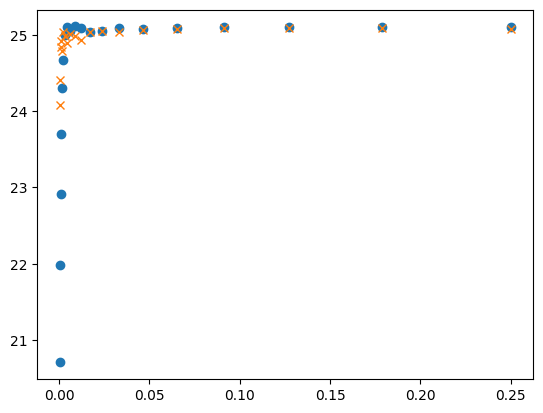

In [ ]:
def gaussian_psf(ksize=15, sigma=1.6, device="cpu"):
    coords = torch.arange(ksize, device=device).float() - (ksize - 1) / 2
    g = torch.exp(-(coords**2) / (2 * sigma**2))
    kernel = g.view(-1, 1) * g.view(1, -1)
    kernel /= kernel.sum()
    return kernel.view(1, 1, ksize, ksize)


def solve_fidelity_fft(y, z, psf, mu, eps=1e-8):
    _, _, H, W = y.shape
    device = y.device
    ksize = psf.shape[-1]
    p = ksize // 2

    psf_padded = torch.zeros((1, 1, H, W), device=device, dtype=y.dtype)
    psf_padded[:, :, :ksize, :ksize] = psf

    psf_padded = torch.roll(psf_padded, shifts=(-p, -p), dims=(-2, -1))

    Y = torch.fft.fft2(y, dim=(-2, -1))
    Z = torch.fft.fft2(z, dim=(-2, -1))
    H_fft = torch.fft.fft2(psf_padded, dim=(-2, -1))

    H_conj = torch.conj(H_fft)
    denominator = torch.abs(H_fft)**2 + mu + eps
    x_hat = (H_conj * Y + mu * Z) / denominator

    return torch.real(torch.fft.ifft2(x_hat, dim=(-2, -1))).clamp(0,1)


class IRCNNModelManager:
    def __init__(self, model_dir, device="cpu"):
        self.model_dir = model_dir
        self.device = device
        self.available_sigmas = [2*i for i in range(1,26)]
        self.model = IRCNNFixed(n_filters=64).to(device)
        self.current_sigma = None

    def get_expert(self, target_sigma):
        closest = min(self.available_sigmas, key=lambda x: abs(x - target_sigma))
        if closest != self.current_sigma:
            path = os.path.join(self.model_dir, f"ircnn_sigma_{closest}_final.pth")
            state = torch.load(path, map_location=self.device)
            self.model.load_state_dict(state["model"])
            self.model.eval()
            self.current_sigma = closest
        return self.model


def calculate_psnr(x, y, eps=1e-8):
    mse = torch.mean((x - y) ** 2).item()
    return 10.0 * math.log10(1.0 / (mse + eps))


def estimate_sigma(y):
    kernel = torch.tensor([[[[1, -2, 1], [-2, 4, -2], [1, -2, 1]]]], dtype=y.dtype, device=y.device)
    kernel = kernel.repeat(1, 3, 1, 1)

    res = torch.nn.functional.conv2d(y, kernel)

    sigma_est = torch.mean(torch.abs(res)) * (np.sqrt(np.pi / 2) / 6.0)
    return sigma_est

def test_deblur_pnp(
    image_path,
    model_dir=r"./IRCNN_v2/weights_ircnn_experts_colab",
    out_dir=r"./IRCNN_v2/results",
    sigma_n_pixels=2,
    lambda_pnp=1,
    ksize=15
):
    os.makedirs(out_dir, exist_ok=True)
    device = torch.device("cpu")

    img_pil = Image.open(image_path).convert("RGB")
    clean = TF.to_tensor(img_pil).unsqueeze(0).to(device)
    _, _, H, W = clean.shape

    ksize = 15
    p = ksize // 2
    psf = gaussian_psf(ksize=ksize, sigma=5, device=device)

    psf_padded = torch.zeros((1, 1, H, W), device=device)
    psf_padded[:, :, :ksize, :ksize] = psf
    psf_padded = torch.roll(psf_padded, shifts=(-p, -p), dims=(2, 3))

    clean_fft = torch.fft.fft2(clean)
    psf_fft = torch.fft.fft2(psf_padded)
    y_blurred = torch.real(torch.fft.ifft2(clean_fft * psf_fft))

    noise = torch.randn_like(y_blurred) * (sigma_n_pixels / 255.0)
    y = (y_blurred + noise).clamp(0, 1)

    manager = IRCNNModelManager(model_dir, device=device)
    sigmas_k = np.logspace(np.log10(49), np.log10(sigma_n_pixels), 20)

    x = y.clone()
    mus=[]
    psnr1, psnr2=[], []
    print(f"Début du défloutage HQS (30 itérations)...")
    for i, sk in enumerate(sigmas_k):
        mu = lambda_pnp / (sk**2)

        x = solve_fidelity_fft(y, x, psf, mu)
        psnr1.append(calculate_psnr(x, clean))

        expert = manager.get_expert(sk)
        with torch.no_grad():
            x = expert.denoise(x).clamp(0, 1)
        mus.append(mu)
        psnr2.append(calculate_psnr(x, clean))

    psnr_initial = calculate_psnr(y, clean)
    psnr_final = calculate_psnr(x, clean)
    improvement = psnr_final - psnr_initial

    print(f"\n--- Résultats ---")
    print(f"PSNR Initial (Dégradé) : {psnr_initial:.2f} dB")
    print(f"PSNR Final (IRCNN)     : {psnr_final:.2f} dB")
    print(f"Gain                   : {improvement:.2f} dB")

    TF.to_pil_image(y.squeeze(0)).save(os.path.join(out_dir, "input_blurred_noisy.png"))
    TF.to_pil_image(x.squeeze(0)).save(os.path.join(out_dir, "output_deblurred.png"))
    print(f"Terminé ! Images sauvegardées dans le dossier '{out_dir}'.")
    plt.plot(mus,psnr1,'o')
    plt.plot(mus,psnr2,'x')
    plt.show()

test_deblur_pnp(image_path = r"./BSDS300/images/test/271035.jpg")
